# Spam Classification — XGBoost

**Dataset:** SMS Spam Collection (ham/spam labeled).

## 1. Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Load and Explore the Dataset

In [11]:
# Load the dataset
df = pd.read_csv('spam.csv', encoding='latin1')

# Keep only the relevant columns and rename them
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Class distribution
print('Class distribution:')
print(df['label'].value_counts())

# Check for missing values
print('\nMissing values:')
print(df.isnull().sum())

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


## 3. Data Preprocessing

Convert text to numerical features using **TF-IDF** vectorization. Encode labels as binary: `ham = 0`, `spam = 1`.

In [13]:
# Encode labels: ham=0, spam=1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['message'])
y = df['label_encoded']

print('Feature matrix shape:', X.shape)
print('Label distribution:')
print(y.value_counts())

Feature matrix shape: (5572, 5000)
Label distribution:
label_encoded
0    4825
1     747
Name: count, dtype: int64


In [14]:
# Train/Test split (80% train, 20% test) — same split for all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 4457
Test set size: 1115


## 4. XGBoost Classifier

Gradient boosting with `scale_pos_weight` to handle class imbalance.

In [15]:
# Compute class imbalance weight
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Train XGBoost
xgb = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('=== XGBoost Classification Report ===')
print(classification_report(y_test, y_pred_xgb, target_names=['ham', 'spam']))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.94      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 5. Confusion Matrix

Visualize correct and incorrect model predictions.

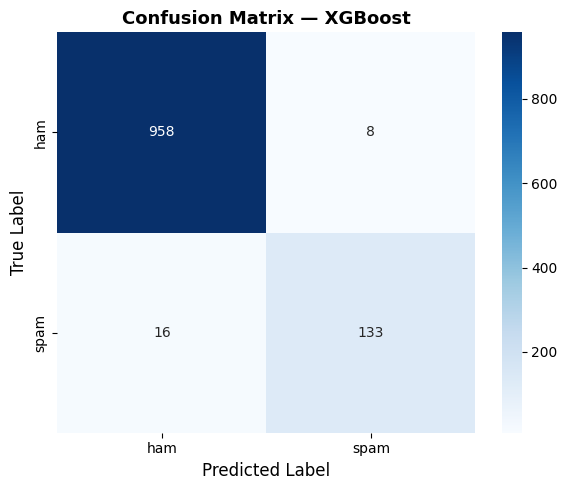

Ham correctement identifié  : 958
 Ham classifié comme spam    : 8
 Spam non détecté (manqué)   : 16
 Spam correctement détecté   : 133


In [19]:
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Ham correctement identifié  : {tn}')
print(f' Ham classifié comme spam    : {fp}')
print(f' Spam non détecté (manqué)   : {fn}')
print(f' Spam correctement détecté   : {tp}')

## 6. Save the Model


In [17]:
import joblib

# Save the model and vectorizer
joblib.dump(xgb, 'xgboost_spam_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## 7. Test on a New Message


In [18]:
# Load the saved model and vectorizer
model = joblib.load('xgboost_spam_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Prediction function
def predict_spam(message):
    msg_vec = vectorizer.transform([message])
    prediction = model.predict(msg_vec)[0]
    proba = model.predict_proba(msg_vec)[0]
    label = 'SPAM' if prediction == 1 else 'HAM (not spam)'
    print(f'Message  : "{message}"')
    print(f'Result   : {label}')
    print(f'Confidence: spam={proba[1]*100:.1f}%  ham={proba[0]*100:.1f}%')
    print()

# Test with multiple messages
predict_spam('Congratulations! You have won a FREE iPhone. Click here to claim now!')
predict_spam('Hey, are we still meeting for lunch tomorrow?')
predict_spam('URGENT: Your account has been suspended. Verify now to avoid charges.')
predict_spam("I'll call you back in 10 minutes.")

Message  : "Congratulations! You have won a FREE iPhone. Click here to claim now!"
Result   : SPAM
Confidence: spam=98.3%  ham=1.7%

Message  : "Hey, are we still meeting for lunch tomorrow?"
Result   : HAM (not spam)
Confidence: spam=1.1%  ham=98.9%

Message  : "URGENT: Your account has been suspended. Verify now to avoid charges."
Result   : SPAM
Confidence: spam=61.8%  ham=38.2%

Message  : "I'll call you back in 10 minutes."
Result   : HAM (not spam)
Confidence: spam=0.4%  ham=99.6%

